# **1. Setup & Data Retrieval**


In [21]:
pip install yfinance pandas numpy matplotlib seaborn scipy

In [22]:
import yfinance as yf
import pandas as pd

saham = ['BBCA.JK', 'BBRI.JK', 'TLKM.JK', 'ASII.JK', 'BMRI.JK',
         'UNVR.JK', 'ICBP.JK', 'KLBF.JK', 'EXCL.JK', 'INDF.JK']

df = yf.download(saham, start='2020-01-01', end='2025-12-31')['Close']
df.dropna(how='all', inplace=True)
print(df.shape)  # check data dimensions

/tmp/ipykernel_54595/187525433.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(saham, start='2020-01-01', end='2025-12-31')['Close']
[*********************100%***********************]  10 of 10 completed

(1447, 10)


#  **2. Cleaning & EDA**

In [23]:
# Check for missing values
print(df.isnull().sum())

# Fill missing values with forward fill (previous day's price)
df.ffill(inplace=True)

# Calculate daily returns
returns = df.pct_change().dropna()

# Descriptive statistics
print(returns.describe())

Ticker
ASII.JK    0
BBCA.JK    0
BBRI.JK    0
BMRI.JK    0
EXCL.JK    0
ICBP.JK    0
INDF.JK    0
KLBF.JK    0
TLKM.JK    0
UNVR.JK    0
dtype: int64
Ticker      ASII.JK      BBCA.JK      BBRI.JK      BMRI.JK      EXCL.JK  \
count   1446.000000  1446.000000  1446.000000  1446.000000  1446.000000   
mean       0.000460     0.000367     0.000400     0.000652     0.000554   
std        0.020315     0.016574     0.021446     0.021815     0.025679   
min       -0.114537    -0.085294    -0.101235    -0.129921    -0.092511   
25%       -0.010638    -0.008664    -0.010695    -0.010399    -0.013043   
50%        0.000000     0.000000     0.000000     0.000000     0.000000   
75%        0.011019     0.008469     0.010057     0.011572     0.011976   
max        0.127072     0.173333     0.204918     0.158031     0.248227   

Ticker      ICBP.JK      INDF.JK      KLBF.JK      TLKM.JK      UNVR.JK  
count   1446.000000  1446.000000  1446.000000  1446.000000  1446.000000  
mean       0.000037     0.

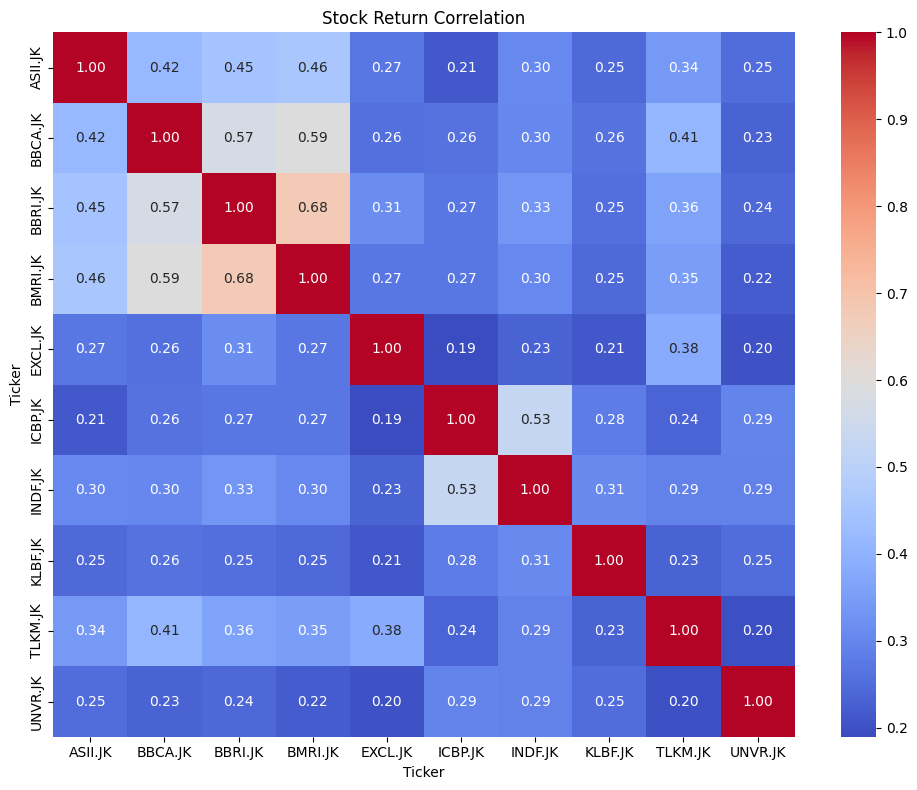

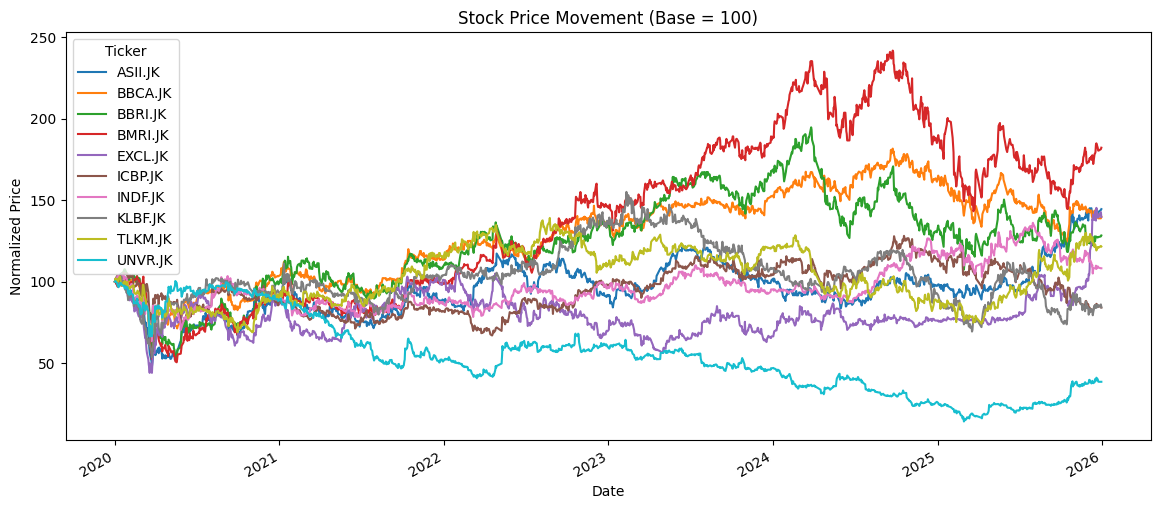

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation heatmap between stocks
plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Stock Return Correlation')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)

# 2. Price movement (normalized to 100)
normalized = (df / df.iloc[0]) * 100
normalized.plot(figsize=(14, 6))
plt.title('Stock Price Movement (Base = 100)')
plt.ylabel('Normalized Price')
plt.savefig('normalized_price.png', dpi=150)

# **3. Risk & Return Calculation**

In [25]:
import numpy as np

# Annualized return & volatility
annual_return = returns.mean() * 252
annual_vol = returns.std() * np.sqrt(252)

# Sharpe Ratio (assuming Indonesian risk-free rate ~6%)
risk_free = 0.06
sharpe = (annual_return - risk_free) / annual_vol

summary = pd.DataFrame({
    'Annual Return (%)': (annual_return * 100).round(2),
    'Volatility (%)': (annual_vol * 100).round(2),
    'Sharpe Ratio': sharpe.round(3)
}).sort_values('Sharpe Ratio', ascending=False)

print(summary)
summary.to_csv('stock_summary.csv', index=True)  # For future use in Tableau

         Annual Return (%)  Volatility (%)  Sharpe Ratio
Ticker                                                  
BMRI.JK              16.43           34.63         0.301
EXCL.JK              13.97           40.76         0.195
ASII.JK              11.59           32.25         0.173
BBCA.JK               9.25           26.31         0.124
BBRI.JK              10.08           34.05         0.120
TLKM.JK               8.33           31.58         0.074
INDF.JK               5.30           28.18        -0.025
KLBF.JK               3.44           36.09        -0.071
ICBP.JK               0.93           28.24        -0.180
UNVR.JK              -8.94           39.61        -0.377


# **4. Monte Carlo Simulation**

In [26]:
np.random.seed(42)
n_portfolio = 5000
n_assets = len(saham)

results = np.zeros((3, n_portfolio))
weights_record = []

for i in range(n_portfolio):
    w = np.random.random(n_assets)
    w /= w.sum()  # Normalize so the total = 100%
    weights_record.append(w)

    port_return = np.dot(w, annual_return)
    port_vol = np.sqrt(w @ returns.cov() * 252 @ w)
    port_sharpe = (port_return - risk_free) / port_vol

    results[0, i] = port_vol
    results[1, i] = port_return
    results[2, i] = port_sharpe

# Find the optimal portfolio (highest Sharpe ratio)
max_idx = results[2].argmax()
opt_weights = weights_record[max_idx]
opt_return = results[1, max_idx]
opt_vol = results[0, max_idx]

print(f"\nOptimal Portfolio:")
print(f"Return: {opt_return*100:.2f}%")
print(f"Volatility: {opt_vol*100:.2f}%")
print(f"Sharpe Ratio: {results[2, max_idx]:.3f}")

for ticker, w in zip(saham, opt_weights):
    print(f"  {ticker}: {w*100:.1f}%")


Optimal Portfolio:
Return: 11.57%
Volatility: 23.76%
Sharpe Ratio: 0.234
  BBCA.JK: 9.4%
  BBRI.JK: 12.7%
  TLKM.JK: 8.9%
  ASII.JK: 28.6%
  BMRI.JK: 23.7%
  UNVR.JK: 4.8%
  ICBP.JK: 0.2%
  KLBF.JK: 1.2%
  EXCL.JK: 7.1%
  INDF.JK: 3.3%


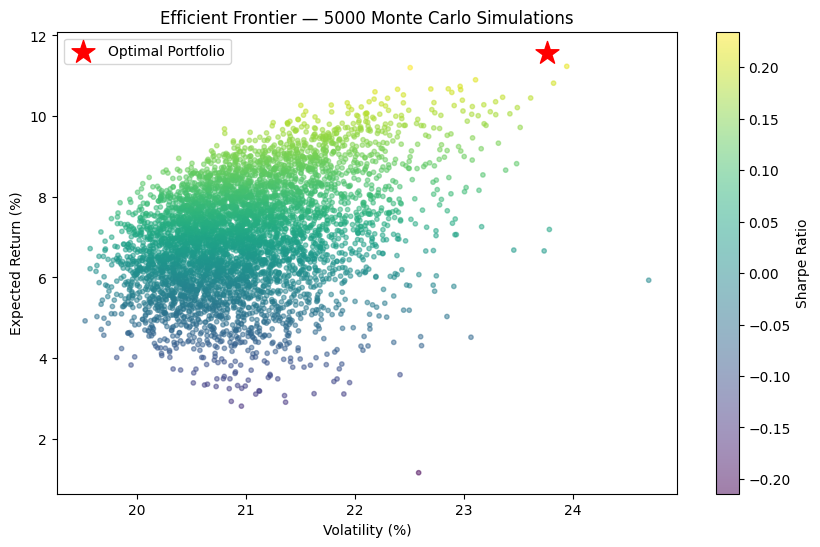

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(results[0]*100, results[1]*100,
            c=results[2], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(opt_vol*100, opt_return*100,
            color='red', marker='*', s=300, label='Optimal Portfolio')
plt.xlabel('Volatility (%)')
plt.ylabel('Expected Return (%)')
plt.title('Efficient Frontier — 5000 Monte Carlo Simulations')
plt.legend()
plt.savefig('efficient_frontier.png', dpi=150)

# **5. Export to Tableau/Power BI**

In [28]:
# Export all data required for the dashboard
returns_reset = returns.reset_index()
returns_reset.to_csv('daily_returns.csv', index=False)

df.reset_index().to_csv('stock_price.csv', index=False)

summary.to_csv('stock_summary.csv')

# Monte Carlo results
mc_df = pd.DataFrame({
    'Volatility': results[0]*100,
    'Return': results[1]*100,
    'Sharpe': results[2]
})
mc_df.to_csv('monte_carlo.csv', index=False)

# **6. Key Findings**

## **Best Sharpe Ratio Stock**

In [29]:
print(summary)

         Annual Return (%)  Volatility (%)  Sharpe Ratio
Ticker                                                  
BMRI.JK              16.43           34.63         0.301
EXCL.JK              13.97           40.76         0.195
ASII.JK              11.59           32.25         0.173
BBCA.JK               9.25           26.31         0.124
BBRI.JK              10.08           34.05         0.120
TLKM.JK               8.33           31.58         0.074
INDF.JK               5.30           28.18        -0.025
KLBF.JK               3.44           36.09        -0.071
ICBP.JK               0.93           28.24        -0.180
UNVR.JK              -8.94           39.61        -0.377


In [30]:
best_sharpe_stock = summary['Sharpe Ratio'].idxmax()
best_sharpe_value = summary['Sharpe Ratio'].max()

print("Best Sharpe Ratio stock:", best_sharpe_stock)
print("Sharpe Ratio:", round(best_sharpe_value, 3))

Best Sharpe Ratio stock: BMRI.JK
Sharpe Ratio: 0.301


## **Highest Volatility**

In [31]:
highest_vol_stock = summary['Volatility (%)'].idxmax()
highest_vol_value = summary['Volatility (%)'].max()

print("Highest volatility stock:", highest_vol_stock)
print("Volatility:", round(highest_vol_value, 2), "%")

Highest volatility stock: EXCL.JK
Volatility: 40.76 %


## **Lowest Correlation Pair**

In [32]:
corr_matrix = returns.corr()

# Remove diagonal & duplicate pairs
corr_unstack = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

lowest_pair = corr_unstack.stack().idxmin()
lowest_corr = corr_unstack.stack().min()

print("Lowest correlation pair:", lowest_pair)
print("Correlation:", round(lowest_corr, 3))

Lowest correlation pair: ('EXCL.JK', 'ICBP.JK')
Correlation: 0.19


## **Optimal Portfolio**

In [33]:
max_sharpe_idx = np.argmax(results[2])

opt_vol = results[0, max_sharpe_idx]
opt_return = results[1, max_sharpe_idx]
opt_sharpe = results[2, max_sharpe_idx]

# Weight optimal portfolio
optimal_weights = weights_record[max_sharpe_idx]

optimal_df = pd.DataFrame({
    'Stock': saham,
    'Weight (%)': (optimal_weights * 100).round(2)
}).sort_values('Weight (%)', ascending=False)

print("Optimal Portfolio")
print("Return:", round(opt_return * 100, 2), "%")
print("Volatility:", round(opt_vol * 100, 2), "%")
print("Sharpe Ratio:", round(opt_sharpe, 3))

print(optimal_df)

Optimal Portfolio
Return: 11.57 %
Volatility: 23.76 %
Sharpe Ratio: 0.234
     Stock  Weight (%)
3  ASII.JK       28.65
4  BMRI.JK       23.68
1  BBRI.JK       12.74
0  BBCA.JK        9.38
2  TLKM.JK        8.94
8  EXCL.JK        7.10
5  UNVR.JK        4.79
9  INDF.JK        3.32
7  KLBF.JK        1.24
6  ICBP.JK        0.16


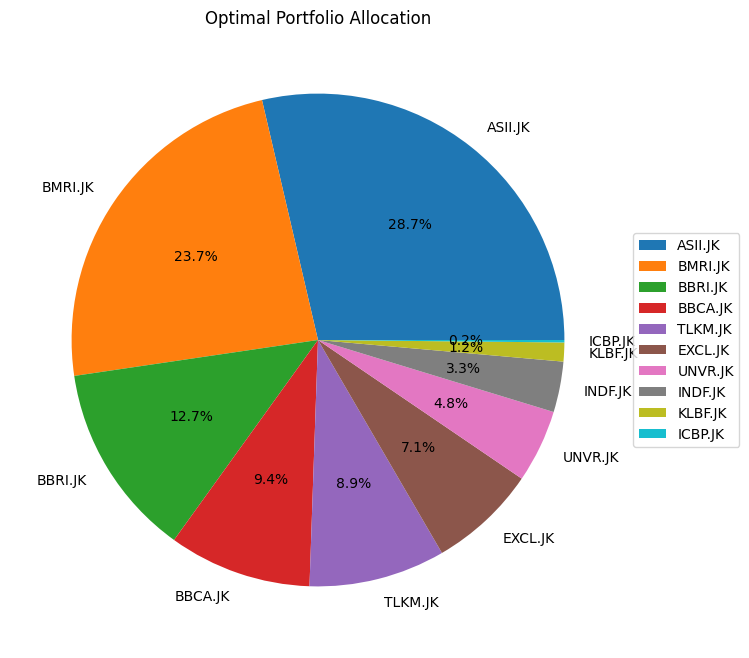

In [39]:
optimal_df.plot.pie(
    y='Weight (%)',
    labels=optimal_df['Stock'],
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.title('Optimal Portfolio Allocation')
plt.ylabel('')
plt.show()